# 🔢 Ulam Prime Spiral
### Primes hiding in diagonals — discovered by accident in 1963

`Number Theory` · `Quadratic Polynomials` · `Fourier Analysis` · `Unsolved Mathematics`

---

## What Is Actually Happening?

### The Accidental Discovery

In 1963, Stanisław Ulam was sitting through a dull conference lecture. He doodled on a notepad — integers in a clockwise outward spiral — then circled the primes. He immediately ran it on a Los Alamos computer.

**The primes were lining up along diagonals.** Not every prime — but far more than chance would predict if primes were truly random.

### Why Diagonals Appear

In the spiral layout, every diagonal corresponds to integers of the form **an² + bn + c** for fixed (a, b, c). Each diagonal is exactly a quadratic polynomial. If that polynomial generates prime-dense output, its diagonal lights up.

Euler's famous example:
```
n² − n + 41   is prime for every n from 0 to 40

n=0:  41  ✓      n=1:  41  ✓      n=10: 131 ✓
n=20: 421 ✓      n=40: 1601 ✓
n=41: 1681 = 41 × 41   ✗   (the streak finally breaks)
```

This polynomial appears as a bright diagonal streak in the spiral. No one designed it — it emerges from arithmetic.

### The Fourier Proof

The 2D Discrete Fourier Transform of the prime grid converts the spatial pattern into frequency components. If primes were truly random, the power spectrum would be a **featureless uniform disk**. Instead, it shows sharp off-axis spikes at the diagonal angles — mathematically proving the structure is a genuine arithmetical periodicity, not an optical illusion.

### The Open Mystery

The **Bateman-Horn conjecture** predicts the asymptotic prime density of any polynomial but has never been proved. The **Riemann Hypothesis**, after 166 years, still waits.

> **Three panels below:** full spiral · centre zoom showing individual diagonals · Fourier power spectrum proving they're real

---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from IPython.display import HTML, display
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#03020a',
    'axes.facecolor':    '#03020a',
    'axes.edgecolor':    '#1a0a30',
    'text.color':        '#c8b8ff',
    'axes.labelcolor':   '#c8b8ff',
    'xtick.color':       '#5030a0',
    'ytick.color':       '#5030a0',
    'font.family':       'monospace',
})
print("Ready.")

Ready.


Building Ulam spiral (601×601 = 361,201 integers) ... done.  30,835 primes  (8.5% of range)


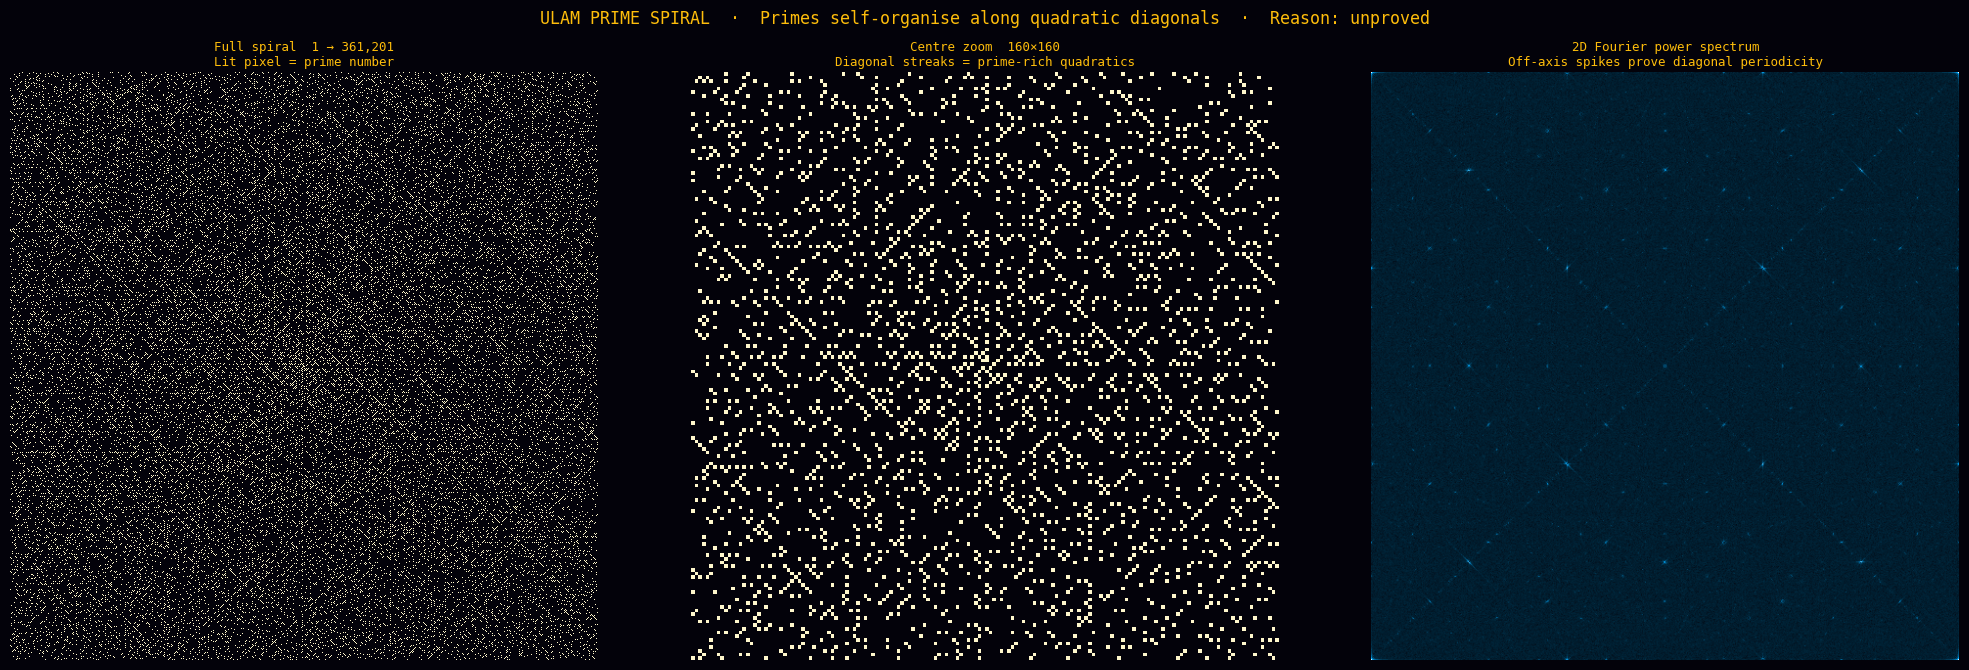

Primes are not random.
The Riemann Hypothesis would partially explain why. After 166 years — still open.


In [10]:
def sieve(n):
    p = np.ones(n+1, dtype=bool)
    p[0] = p[1] = False
    for i in range(2, int(n**0.5)+1):
        if p[i]: p[i*i::i] = False
    return p

def build_ulam(side=601):
    # Arrange integers 1..side² in clockwise outward spiral,
    # mark each cell 1 if its integer is prime, else 0.
    N = side * side
    primes = sieve(N + 4)
    grid = np.zeros((side, side), np.float32)
    x = y = side // 2
    n = 1;  step = 1;  count = 0;  di = 0;  turns = 0
    dirs = [(0,1), (-1,0), (0,-1), (1,0)]   # right, up, left, down
    for _ in range(N):
        if 0 <= y < side and 0 <= x < side and primes[n]:
            grid[y, x] = 1.0
        dx, dy = dirs[di % 4]
        x += dx;  y += dy;  n += 1;  count += 1
        if count == step:
            count = 0;  di += 1;  turns += 1
            if turns % 2 == 0: step += 1
    return grid

print("Building Ulam spiral (601×601 = 361,201 integers) ...", end=" ")
grid = build_ulam(601)
pc = int(grid.sum())
print(f"done.  {pc:,} primes  ({100*pc/601**2:.1f}% of range)")

cu = LinearSegmentedColormap.from_list("ul",
    ["#03020a","#1a0a00","#804000","#ffbe0b","#fff7cc"])

fig, axes = plt.subplots(1, 3, figsize=(21, 7), facecolor='#03020a')
fig.subplots_adjust(left=.02, right=.98, top=.88, bottom=.04, wspace=.04)

# Full spiral
axes[0].imshow(grid, cmap=cu, origin='lower', interpolation='nearest')
axes[0].set_title("Full spiral  1 → 361,201\nLit pixel = prime number",
                  color='#ffbe0b', fontsize=9, pad=5)
axes[0].axis('off')

# Centre zoom
c = 601 // 2;  z = 80
axes[1].imshow(grid[c-z:c+z, c-z:c+z], cmap=cu, origin='lower', interpolation='nearest')
axes[1].set_title("Centre zoom  160×160\nDiagonal streaks = prime-rich quadratics",
                  color='#ffbe0b', fontsize=9, pad=5)
axes[1].axis('off')

# 2D Fourier power spectrum
from numpy.fft import fft2, fftshift
spec = np.abs(fftshift(fft2(grid - grid.mean()))) ** 0.3
cf = LinearSegmentedColormap.from_list("ft", ["#03020a","#002a40","#00aaff","#fff"])
axes[2].imshow(spec, cmap=cf, origin='lower', interpolation='bilinear')
axes[2].set_title("2D Fourier power spectrum\nOff-axis spikes prove diagonal periodicity",
                  color='#ffbe0b', fontsize=9, pad=5)
axes[2].axis('off')

fig.suptitle("ULAM PRIME SPIRAL  ·  Primes self-organise along quadratic diagonals  ·  Reason: unproved",
             color='#ffbe0b', fontsize=12, y=.97)
plt.show()
print("Primes are not random.")
print("The Riemann Hypothesis would partially explain why. After 166 years — still open.")